Analyze results of optimize_tkg.py

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import json
import os

from optimize_tkg import prepare_target_metrics

/nas/ckgfs/users/eboxer/synthetic_tkg_patterns/env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Optuna


In [3]:
%matplotlib inline

# Utilities

In [4]:
def _safe_read_json(path, default=None):
    if os.path.exists(path):
        try:
            with open(path, "r") as f:
                return json.load(f)
        except Exception:
            return default
    return default

# opt_runs_icews18_20250926

In [5]:
data_dir = './opt_runs_icews18_20250926'
dir_real = '/nas/ckgfs/users/eboxer/TKG-Forecasting-Evaluation/data/ICEWS18'

In [6]:
trials = os.listdir(data_dir)

summary = {
    'trial_id': [],
    'score': [],
}
for trial in trials:
    if not trial.startswith('trial'):
        continue
    trial_dir = os.path.join(data_dir, trial)

    try:
        with open(os.path.join(trial_dir, 'score.txt'), 'r') as f:
            score = float(f.readline().strip())
        summary['score'].append(score)

        summary['trial_id'].append(int(trial.split('_')[1]))
    except FileNotFoundError:
        pass

df_summary = pd.DataFrame(summary)
print(df_summary.shape)
df_summary[:3]

(200, 2)


,trial_id,score
0,0,5.338987
1,1,19.966998
2,2,23.697051


<Axes: xlabel='trial_id'>

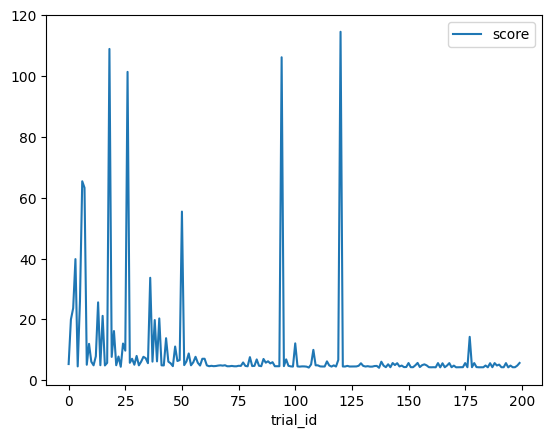

In [7]:
df_summary.plot(x='trial_id', y='score')
# plt.yscale('log')

In [8]:
# Reference baselines (once per export_root)
ref_baselines = _safe_read_json(os.path.join(data_dir, "target_baselines.json"), default={})

# Gather *all* trial folders
trial_dirs = sorted(
    [d for d in os.listdir(data_dir) if d.startswith("trial_") and os.path.isdir(os.path.join(data_dir, d))],
    key=lambda s: int(s.split("_")[1]) if "_" in s and s.split("_")[1].isdigit() else 10**12
)

rows = []
for tdir in trial_dirs:
    tid = int(tdir.split("_")[1])
    tpath = os.path.join(data_dir, tdir)

    score = None
    score_path = os.path.join(tpath, "score.txt")
    if os.path.exists(score_path):
        try:
            with open(score_path, "r") as f:
                score = float(f.readline().strip())
        except Exception:
            pass

    # These files are written by optimize_tkg.py’s _write_trial_artifacts and your baseline hook
    syn_metrics = _safe_read_json(os.path.join(tpath, "syn_metrics.json"), default={})
    params = _safe_read_json(os.path.join(tpath, "trial_params.json"), default={})
    syn_baselines = _safe_read_json(os.path.join(tpath, "syn_baselines.json"), default={})

    rows.append({
        "trial_id": tid,
        "score": score,
        "metrics": syn_metrics,
        "params": params,
        "baselines": syn_baselines
    })

In [9]:
if 'dir_real' in globals() and prepare_target_metrics is not None:
    real_metrics = prepare_target_metrics(dir_real)
    rows = ([{
        "trial_id": "real",
        "score": None,
        "metrics": real_metrics,
        "params": {},
        "baselines": ref_baselines
    }] + rows)

# Build the wide dataframe
df_metrics = pd.DataFrame(rows)

# Normalize nested dict columns into flat columns
df_metrics = df_metrics.join(pd.json_normalize(df_metrics.pop("metrics")).add_prefix(""))
df_metrics = df_metrics.join(pd.json_normalize(df_metrics.pop("params")).add_suffix("_param"))
df_metrics = df_metrics.join(pd.json_normalize(df_metrics.pop("baselines")).add_prefix("baseline:"))
print(df_metrics.shape)

(201, 38)


In [10]:
pd.set_option('display.max_columns', 50)

In [11]:
df_metrics[:3]

,trial_id,score,n_ents,n_rels,n_tws,n_quads,n_unique_triples,avg_degree,deg_p25,deg_p75,seed_base_param,n_ents_param,n_rels_param,n_tws_param,_pat_distr_ents_choice_param,_pat_distr_rels_choice_param,n_1_hop_param,n_2_hop_param,n_3_hop_param,require_unique_triples_param,prohibit_selfconnections_param,prohibit_new_consequence_relations_param,require_sequential_rule_param,use_density_dist_param,rnd_avg_density_param,p_skip_consequence_param,use_force_distr_param,p_force_param,n_force_param,baseline:recency@1,baseline:recency@3,baseline:recency@10,baseline:frequency(h=3)@1,baseline:frequency(h=3)@3,baseline:frequency(h=3)@10,baseline:frequency(h=10)@1,baseline:frequency(h=10)@3,baseline:frequency(h=10)@10
0,real,NaN,23033,256,304,468558,266631,40.685799,1.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.162579,0.286971,0.402099,0.166737,0.272621,0.272621,0.183389,0.300535,0.374992
1,0,5.338987,19726,162,304,72526,72478,7.353341,3.0,10.0,0.0,23033.0,256.0,304.0,"gamma(2,2)","gamma(0.5,1.0)",24.0,278.0,181.0,True,True,True,False,False,0.0,0.0,False,0.05,3.0,0.000000,0.000400,0.000400,0.000000,0.000400,0.000400,0.000000,0.000400,0.000400
2,1,19.966998,18726,232,304,813426,812360,86.876642,8.0,114.0,0.0,23033.0,256.0,304.0,empirical,uniform,257.0,12.0,61.0,True,False,False,True,False,0.0,0.0,False,0.85,4.0,0.001000,0.001000,0.001000,0.001000,0.001000,0.001000,0.001000,0.001000,0.001000


In [12]:
pd.concat([
    df_metrics[:1],
    df_metrics.sort_values(['score'], ascending=True)[:10]
], axis=0)

,trial_id,score,n_ents,n_rels,n_tws,n_quads,n_unique_triples,avg_degree,deg_p25,deg_p75,seed_base_param,n_ents_param,n_rels_param,n_tws_param,_pat_distr_ents_choice_param,_pat_distr_rels_choice_param,n_1_hop_param,n_2_hop_param,n_3_hop_param,require_unique_triples_param,prohibit_selfconnections_param,prohibit_new_consequence_relations_param,require_sequential_rule_param,use_density_dist_param,rnd_avg_density_param,p_skip_consequence_param,use_force_distr_param,p_force_param,n_force_param,baseline:recency@1,baseline:recency@3,baseline:recency@10,baseline:frequency(h=3)@1,baseline:frequency(h=3)@3,baseline:frequency(h=3)@10,baseline:frequency(h=10)@1,baseline:frequency(h=10)@3,baseline:frequency(h=10)@10
0,real,NaN,23033,256,304,468558,266631,40.685799,1.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.162579,0.286971,0.402099,0.166737,0.272621,0.272621,0.183389,0.300535,0.374992
138,137,4.112589,14023,246,304,62482,62457,8.911360,2.0,12.0,0.0,23033.0,256.0,304.0,"gamma(0.5,1.0)","gamma(3,1)",218.0,295.0,187.0,True,False,False,True,False,0.0,0.0,False,0.1,1.0,0.000200,0.000200,0.000200,0.000200,0.000200,0.000200,0.000200,0.000200,0.000200
107,106,4.179740,16871,248,304,63066,63065,7.476261,2.0,10.0,0.0,23033.0,256.0,304.0,"gamma(1,2)","gamma(3,1)",254.0,268.0,195.0,True,False,False,True,False,0.0,0.0,False,0.1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
195,194,4.251412,18912,256,304,62472,62472,6.606599,2.0,8.0,0.0,23033.0,256.0,304.0,"gamma(2,2)",uniform,349.0,233.0,172.0,True,True,False,True,False,0.0,0.0,False,0.1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
165,164,4.255824,18865,256,304,62145,62145,6.588391,2.0,8.0,0.0,23033.0,256.0,304.0,"gamma(2,2)",uniform,317.0,247.0,170.0,True,True,False,True,False,0.0,0.0,False,0.1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,171,4.268659,18868,255,304,61081,61081,6.474560,2.0,8.0,0.0,23033.0,256.0,304.0,"gamma(2,2)",uniform,299.0,240.0,170.0,True,True,False,True,False,0.0,0.0,False,0.1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
186,185,4.271300,18779,256,304,60690,60660,6.463603,2.0,8.0,0.0,23033.0,256.0,304.0,"gamma(2,2)",uniform,341.0,230.0,166.0,True,True,False,True,False,0.0,0.0,False,0.1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
163,162,4.273675,18796,255,304,60787,60787,6.468078,2.0,8.0,0.0,23033.0,256.0,304.0,"gamma(2,2)",uniform,312.0,242.0,168.0,True,True,False,True,False,0.0,0.0,False,0.1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
161,160,4.274350,18842,255,304,60518,60518,6.423734,2.0,8.0,0.0,23033.0,256.0,304.0,"gamma(2,2)",uniform,287.0,246.0,178.0,True,True,False,True,False,0.0,0.0,False,0.1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
182,181,4.278029,18729,255,304,60517,60486,6.462385,2.0,8.0,0.0,23033.0,256.0,304.0,"gamma(2,2)",uniform,314.0,240.0,169.0,True,True,False,True,False,0.0,0.0,False,0.1,1.0,0.000400,0.000400,0.000400,0.000400,0.000400,0.000400,0.000400,0.000400,0.000400


In [13]:
df_metrics.sort_values(['baseline:recency@1'], ascending=False)[:10]

,trial_id,score,n_ents,n_rels,n_tws,n_quads,n_unique_triples,avg_degree,deg_p25,deg_p75,seed_base_param,n_ents_param,n_rels_param,n_tws_param,_pat_distr_ents_choice_param,_pat_distr_rels_choice_param,n_1_hop_param,n_2_hop_param,n_3_hop_param,require_unique_triples_param,prohibit_selfconnections_param,prohibit_new_consequence_relations_param,require_sequential_rule_param,use_density_dist_param,rnd_avg_density_param,p_skip_consequence_param,use_force_distr_param,p_force_param,n_force_param,baseline:recency@1,baseline:recency@3,baseline:recency@10,baseline:frequency(h=3)@1,baseline:frequency(h=3)@3,baseline:frequency(h=3)@10,baseline:frequency(h=10)@1,baseline:frequency(h=10)@3,baseline:frequency(h=10)@10
0,real,NaN,23033,256,304,468558,266631,40.685799,1.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.162579,0.286971,0.402099,0.166737,0.272621,0.272621,0.183389,0.300535,0.374992
4,3,39.817876,22510,248,304,1015649,993152,90.239805,26.0,125.0,0.0,23033.0,256.0,304.0,"gamma(1,2)",uniform,248.0,39.0,128.0,True,False,False,False,False,0.0,0.0,False,0.75,4.0,0.024800,0.035600,0.036000,0.025200,0.035600,0.035600,0.026200,0.035800,0.036000
3,2,23.697051,20297,246,304,797358,779027,78.569050,13.0,105.0,0.0,23033.0,256.0,304.0,"gamma(0.5,1.0)",uniform,328.0,215.0,7.0,True,False,True,False,False,0.0,0.0,False,0.40,5.0,0.022400,0.039800,0.040600,0.023200,0.039800,0.039800,0.024800,0.040000,0.040600
10,9,11.977832,19158,255,304,414643,410669,43.286669,8.0,58.0,0.0,23033.0,256.0,304.0,"gamma(0.5,1.0)",uniform,344.0,281.0,110.0,True,False,True,False,False,0.0,0.0,False,0.35,2.0,0.011600,0.018200,0.018200,0.011600,0.018200,0.018200,0.011800,0.018200,0.018200
48,47,11.093864,22612,154,304,207198,205657,18.326375,9.0,25.0,0.0,23033.0,256.0,304.0,"gamma(3,1)","gamma(1,2)",58.0,96.0,42.0,True,False,False,False,False,0.0,0.0,False,0.30,4.0,0.008600,0.012800,0.012800,0.008600,0.012800,0.012800,0.008600,0.012800,0.012800
78,77,5.857736,13516,214,304,129613,128979,19.179195,3.0,27.0,0.0,23033.0,256.0,304.0,empirical,"gamma(2,2)",50.0,176.0,150.0,True,False,False,False,False,0.0,0.0,False,0.35,1.0,0.005200,0.007800,0.007800,0.005200,0.007800,0.007800,0.005200,0.007800,0.007800
39,38,19.795896,22929,219,304,368878,367357,32.175673,17.0,43.0,0.0,23033.0,256.0,304.0,"gamma(3,1)","gamma(2,2)",257.0,89.0,145.0,True,False,True,False,False,0.0,0.0,False,0.45,2.0,0.003200,0.006400,0.006400,0.003200,0.006400,0.006400,0.003200,0.006400,0.006400
130,129,5.594682,11072,242,304,64135,63970,11.585079,3.0,17.0,0.0,23033.0,256.0,304.0,empirical,"gamma(3,1)",210.0,300.0,198.0,True,False,False,False,False,0.0,0.0,False,0.10,1.0,0.002800,0.004000,0.004000,0.002800,0.004000,0.004000,0.002800,0.004000,0.004000
90,89,5.547081,9944,224,304,45770,45671,9.205551,3.0,13.0,0.0,23033.0,256.0,304.0,empirical,"gamma(2,2)",49.0,212.0,193.0,True,False,False,False,False,0.0,0.0,False,0.10,1.0,0.002757,0.003818,0.003818,0.002757,0.003818,0.003818,0.002757,0.003818,0.003818
108,107,5.209848,16386,246,304,62046,61952,7.573050,3.0,10.0,0.0,23033.0,256.0,304.0,"gamma(1,2)","gamma(3,1)",233.0,277.0,195.0,True,False,False,False,False,0.0,0.0,False,0.10,1.0,0.002600,0.002800,0.002800,0.002600,0.002800,0.002800,0.002600,0.002800,0.002800


# opt_runs_icews14_20250930

In [14]:
data_dir = './opt_runs_icews14_20250930'
dir_real = '/nas/ckgfs/users/eboxer/TKG-Forecasting-Evaluation/data/ICEWS14'

In [15]:
trials = os.listdir(data_dir)

summary = {
    'trial_id': [],
    'score': [],
}
for trial in trials:
    if not trial.startswith('trial'):
        continue
    trial_dir = os.path.join(data_dir, trial)

    try:
        with open(os.path.join(trial_dir, 'score.txt'), 'r') as f:
            score = float(f.readline().strip())
        summary['score'].append(score)

        summary['trial_id'].append(int(trial.split('_')[1]))
    except FileNotFoundError:
        pass

df_summary = pd.DataFrame(summary)
print(df_summary.shape)
df_summary[:3]

(200, 2)


,trial_id,score
0,0,4.498056
1,1,184.864867
2,2,35.846026


<Axes: xlabel='trial_id'>

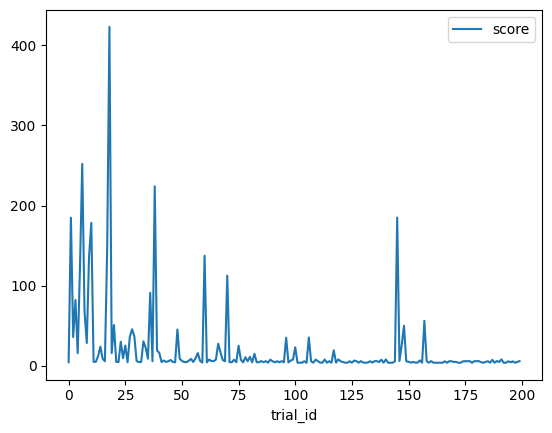

In [16]:
df_summary.plot(x='trial_id', y='score')
# plt.yscale('log')

In [17]:
# Reference baselines (once per export_root)
ref_baselines = _safe_read_json(os.path.join(data_dir, "target_baselines.json"), default={})

# Gather *all* trial folders
trial_dirs = sorted(
    [d for d in os.listdir(data_dir) if d.startswith("trial_") and os.path.isdir(os.path.join(data_dir, d))],
    key=lambda s: int(s.split("_")[1]) if "_" in s and s.split("_")[1].isdigit() else 10**12
)

rows = []
for tdir in trial_dirs:
    tid = int(tdir.split("_")[1])
    tpath = os.path.join(data_dir, tdir)

    score = None
    score_path = os.path.join(tpath, "score.txt")
    if os.path.exists(score_path):
        try:
            with open(score_path, "r") as f:
                score = float(f.readline().strip())
        except Exception:
            pass

    # These files are written by optimize_tkg.py’s _write_trial_artifacts and your baseline hook
    syn_metrics = _safe_read_json(os.path.join(tpath, "syn_metrics.json"), default={})
    params = _safe_read_json(os.path.join(tpath, "trial_params.json"), default={})
    syn_baselines = _safe_read_json(os.path.join(tpath, "syn_baselines.json"), default={})

    rows.append({
        "trial_id": tid,
        "score": score,
        "metrics": syn_metrics,
        "params": params,
        "baselines": syn_baselines
    })

In [18]:
if 'dir_real' in globals() and prepare_target_metrics is not None:
    real_metrics = prepare_target_metrics(dir_real)
    rows = ([{
        "trial_id": "real",
        "score": None,
        "metrics": real_metrics,
        "params": {},
        "baselines": ref_baselines
    }] + rows)

# Build the wide dataframe
df_metrics = pd.DataFrame(rows)

# Normalize nested dict columns into flat columns
df_metrics = df_metrics.join(pd.json_normalize(df_metrics.pop("metrics")).add_prefix(""))
df_metrics = df_metrics.join(pd.json_normalize(df_metrics.pop("params")).add_suffix("_param"))
df_metrics = df_metrics.join(pd.json_normalize(df_metrics.pop("baselines")).add_prefix("baseline:"))
print(df_metrics.shape)

(201, 38)


In [19]:
pd.set_option('display.max_columns', 50)

In [20]:
df_metrics[:3]

,trial_id,score,n_ents,n_rels,n_tws,n_quads,n_unique_triples,avg_degree,deg_p25,deg_p75,seed_base_param,n_ents_param,n_rels_param,n_tws_param,_pat_distr_ents_choice_param,_pat_distr_rels_choice_param,n_1_hop_param,n_2_hop_param,n_3_hop_param,require_unique_triples_param,prohibit_selfconnections_param,prohibit_new_consequence_relations_param,require_sequential_rule_param,use_density_dist_param,rnd_avg_density_param,p_skip_consequence_param,use_force_distr_param,p_force_param,n_force_param,baseline:recency@1,baseline:recency@3,baseline:recency@10,baseline:frequency(h=3)@1,baseline:frequency(h=3)@3,baseline:frequency(h=3)@10,baseline:frequency(h=10)@1,baseline:frequency(h=10)@3,baseline:frequency(h=10)@10
0,real,NaN,7128,230,365,90730,50295,25.457351,1.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.282594,0.405101,0.487315,0.288156,0.384751,0.384751,0.293854,0.411206,0.464387
1,0,4.498056,5895,207,365,12501,12501,4.241221,2.0,6.0,0.0,7128.0,230.0,365.0,uniform,uniform,101.0,17.0,114.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1,184.864867,7128,177,365,571665,571127,160.399832,148.0,173.0,0.0,7128.0,230.0,365.0,uniform,"gamma(1,2)",295.0,122.0,44.0,True,True,False,False,False,0.0,0.0,False,0.35,4.0,0.000600,0.000600,0.000600,0.000600,0.000600,0.000600,0.000400,0.000600,0.000600


In [21]:
pd.concat([
    df_metrics[:1],
    df_metrics.sort_values(['score'], ascending=True)[:10]
], axis=0)

,trial_id,score,n_ents,n_rels,n_tws,n_quads,n_unique_triples,avg_degree,deg_p25,deg_p75,seed_base_param,n_ents_param,n_rels_param,n_tws_param,_pat_distr_ents_choice_param,_pat_distr_rels_choice_param,n_1_hop_param,n_2_hop_param,n_3_hop_param,require_unique_triples_param,prohibit_selfconnections_param,prohibit_new_consequence_relations_param,require_sequential_rule_param,use_density_dist_param,rnd_avg_density_param,p_skip_consequence_param,use_force_distr_param,p_force_param,n_force_param,baseline:recency@1,baseline:recency@3,baseline:recency@10,baseline:frequency(h=3)@1,baseline:frequency(h=3)@3,baseline:frequency(h=3)@10,baseline:frequency(h=10)@1,baseline:frequency(h=10)@3,baseline:frequency(h=10)@10
0,real,NaN,7128,230,365,90730,50295,25.457351,1.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.282594,0.405101,0.487315,0.288156,0.384751,0.384751,0.293854,0.411206,0.464387
179,178,3.743852,5319,213,365,21059,21059,7.918406,2.0,10.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",189.0,87.0,130.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
106,105,3.752142,5293,208,365,21397,21379,8.085018,2.0,10.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",200.0,109.0,116.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.000465,0.000465,0.000465,0.000465,0.000465,0.000465,0.000465,0.000465,0.000465
168,167,3.763727,5328,209,365,20948,20923,7.863363,2.0,10.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",195.0,99.0,120.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.002343,0.002343,0.002343,0.002343,0.002343,0.002343,0.002343,0.002343,0.002343
173,172,3.765524,5298,207,365,21193,21193,8.000378,2.0,10.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",188.0,100.0,123.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
166,165,3.772653,5303,209,365,20838,20838,7.858948,2.0,10.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",196.0,91.0,122.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
184,183,3.775807,5341,208,365,20802,20787,7.789553,2.0,10.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",180.0,99.0,123.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
174,173,3.777870,5349,207,365,20831,20831,7.788746,2.0,10.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",191.0,98.0,124.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
198,197,3.780260,5307,204,365,21140,21140,7.966836,2.0,10.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",210.0,88.0,123.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
165,164,3.786472,5329,206,365,20772,20753,7.795834,2.0,10.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",194.0,92.0,122.0,True,True,False,True,False,0.0,0.0,False,0.05,1.0,0.000474,0.000474,0.000474,0.000474,0.000474,0.000474,0.000474,0.000474,0.000474


Reference TKGs:
- Have more edges than (the best) synthetic TKGs
- Have more unique edges
- Have a higher average degree
- Have a lower 25th percentile degree
- Hae higher recency and frequency baseline performance

In [22]:
df_metrics.sort_values(['baseline:recency@1'], ascending=False)[:10]

,trial_id,score,n_ents,n_rels,n_tws,n_quads,n_unique_triples,avg_degree,deg_p25,deg_p75,seed_base_param,n_ents_param,n_rels_param,n_tws_param,_pat_distr_ents_choice_param,_pat_distr_rels_choice_param,n_1_hop_param,n_2_hop_param,n_3_hop_param,require_unique_triples_param,prohibit_selfconnections_param,prohibit_new_consequence_relations_param,require_sequential_rule_param,use_density_dist_param,rnd_avg_density_param,p_skip_consequence_param,use_force_distr_param,p_force_param,n_force_param,baseline:recency@1,baseline:recency@3,baseline:recency@10,baseline:frequency(h=3)@1,baseline:frequency(h=3)@3,baseline:frequency(h=3)@10,baseline:frequency(h=10)@1,baseline:frequency(h=10)@3,baseline:frequency(h=10)@10
0,real,NaN,7128,230,365,90730,50295,25.457351,1.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.282594,0.405101,0.487315,0.288156,0.384751,0.384751,0.293854,0.411206,0.464387
39,38,223.989345,7128,157,365,960084,900950,269.383838,154.0,353.0,0.0,7128.0,230.0,365.0,"gamma(3,1)","gamma(1,2)",239.0,12.0,39.0,True,False,True,False,False,0.0,0.0,False,1.00,4.0,0.039000,0.098200,0.105800,0.042800,0.098200,0.098200,0.057800,0.100400,0.105800
7,6,251.948805,7128,180,365,774985,754829,217.448092,201.0,233.0,0.0,7128.0,230.0,365.0,uniform,empirical,59.0,280.0,118.0,True,False,False,False,False,0.0,0.0,False,0.75,2.0,0.026800,0.042400,0.043800,0.028200,0.042400,0.042400,0.029200,0.042600,0.043800
37,36,91.135383,7128,221,365,298228,294881,83.677890,74.0,93.0,0.0,7128.0,230.0,365.0,uniform,"gamma(3,1)",281.0,234.0,95.0,True,False,False,False,False,0.0,0.0,False,0.25,2.0,0.014800,0.020600,0.020600,0.015200,0.020600,0.020600,0.015200,0.020600,0.020600
3,2,35.846026,7088,182,365,191197,188614,53.949492,25.0,73.0,0.0,7128.0,230.0,365.0,"gamma(2,2)","gamma(3,1)",211.0,73.0,30.0,True,False,True,False,False,0.0,0.0,False,0.35,2.0,0.014200,0.027000,0.027600,0.014200,0.027000,0.027000,0.015200,0.027000,0.027600
35,34,22.472361,7128,157,365,89425,88683,25.091190,20.0,30.0,0.0,7128.0,230.0,365.0,uniform,"gamma(1,2)",159.0,74.0,41.0,True,False,False,False,False,0.0,0.0,False,0.35,1.0,0.013200,0.016000,0.016000,0.013200,0.016000,0.016000,0.013200,0.016000,0.016000
41,40,16.215893,6658,174,365,114073,112769,34.266446,11.0,47.0,0.0,7128.0,230.0,365.0,"gamma(1,2)",empirical,195.0,58.0,123.0,True,False,False,False,False,0.0,0.0,False,0.10,3.0,0.013000,0.018800,0.019200,0.013200,0.018800,0.018800,0.013200,0.018800,0.019200
26,25,25.273895,5975,182,365,226759,226200,75.902594,8.0,115.5,0.0,7128.0,230.0,365.0,empirical,"gamma(1,2)",150.0,90.0,171.0,True,True,False,True,False,0.0,0.0,False,0.25,2.0,0.002800,0.003000,0.003000,0.002800,0.003000,0.003000,0.002200,0.003000,0.003000
118,117,19.329194,6779,202,365,140940,140638,41.581354,12.0,58.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",203.0,65.0,93.0,True,True,False,True,False,0.0,0.0,False,0.10,4.0,0.002600,0.002600,0.002600,0.002400,0.002600,0.002600,0.002400,0.002600,0.002600
175,174,5.529269,6160,214,365,42448,42368,13.781818,4.0,18.0,0.0,7128.0,230.0,365.0,"gamma(1,2)","gamma(3,1)",190.0,99.0,124.0,True,True,False,True,False,0.0,0.0,False,0.10,1.0,0.002555,0.002555,0.002555,0.002323,0.002555,0.002555,0.002323,0.002555,0.002555
